## Base_line_Logistics_Model

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression   
from sklearn.metrics import mean_squared_error, r2_score,classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('macro_economic_data.csv')
df.head()

,year,kes_per_usd,fx_lag,fx_depreciation_pct,inflation,reserves_usd,log_reserves,inflation_lag,reserves_lag,reserves_pct_change,fx_dep_z,reserves_change_z,inflation_z,fx_pressure
0,1967,7.14286,7.14286,0.000000e+00,1.759196,7.583000e+07,18.144005,5.014395,52400000.0,44.713740,-0.462027,0.401266,-1.117927,-1.981220
1,1968,7.14286,7.14286,0.000000e+00,0.366712,1.000500e+08,18.421181,1.759196,75830000.0,31.939865,-0.462027,0.205546,-1.294059,-1.961632
2,1969,7.14286,7.14286,0.000000e+00,-0.171501,1.696600e+08,18.949307,0.366712,100050000.0,69.575212,-0.462027,0.782191,-1.362136,-2.606354
3,1970,7.14286,7.14286,0.000000e+00,2.188527,2.198300e+08,19.208365,-0.171501,169660000.0,29.570907,-0.462027,0.169249,-1.063622,-1.694899
4,1971,7.14286,7.14286,-1.173236e-07,3.780206,1.709464e+08,18.956860,2.188527,219830000.0,-22.237019,-0.462027,-0.624546,-0.862295,-0.699776


## Defining the "Crisis" event

We are creating the crisis column using the Fx_pressure index

A common rule of thumb , crisis occurs when the pressure is 2 standard deviation above the mean

In [3]:
# 1. Defining the Crisis Threshold
# Use=ing a threshold of Mean + 2 * Std Dev
mean_p = df['fx_pressure'].mean()
std_p = df['fx_pressure'].std()
threshold = mean_p + (2 * std_p)

# Creating binary flag: 1 if pressure is extreme, 0 otherwise
df['is_crisis'] = (df['fx_pressure'] > threshold).astype(int)

print(f"Threshold set at: {threshold:.2f}")
print(f"Total Crisis events found: {df['is_crisis'].sum()}")

Threshold set at: 2.96
Total Crisis events found: 3


**LEAD LAG ALIGNMENT**

We waant the features of 1970 to predict the crisis of 1971

In [4]:
# Shifting the target BACKWARDS so that row 't' contains 
# features for year 't' but the label for year 't+1'
df['target_next_year'] = df['is_crisis'].shift(-1)

# Dropping the very last year because we don't know if a crisis happened the year after
df_final = df.dropna(subset=['target_next_year'])

## Feature Selection

Using the features that typically "leak" information about an upcoming crash: reserves dropping and inflation rising.

In [5]:
# Selecting features
features = [
    'inflation_lag', 
    'reserves_pct_change', 
    'reserves_change_z', 
    'fx_dep_z',
    'log_reserves'
]

X = df_final[features]
y = df_final['target_next_year']

# Scaling is MANDATORY for Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Time-Series Train/Test Split

We will not use the train_test_split(shuffle=True)
If you shuffle, you are using the future to predict the past. A must "cut" the data at a point in time.

In [11]:
# training on the first 80% of the years and testing on the remaining 20%
#split_point = int(len(df_final) * 0.8)

#X_train, X_test = X_scaled[:split_point], X_scaled[split_point:]
#y_train, y_test = y[:split_point], y[split_point:]

from sklearn.model_selection import train_test_split

# Use stratify=y to ensure both sets have at least one crisis
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, stratify=y, random_state=42
)

print(f"Training on {len(X_train)} years, Testing on {len(X_test)} years")

Training on 42 years, Testing on 15 years


### Fitting the Model and Interpreting

Using class_weight='balanced' because crises are rare; this tells the model to pay extra attention to the "1"s (the crises).

In [12]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability of crisis

### EVALUATION

In a baseline, we care about the Confusion Matrix.

- False Negatives: The model said "Fine" but a crisis happened (Dangerous!).

- False Positives: The model said "Crisis" but it was fine (Expensive False Alarm).

In [13]:
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.2f}")

--- Confusion Matrix ---
[[13  1]
 [ 0  1]]

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96        14
         1.0       0.50      1.00      0.67         1

    accuracy                           0.93        15
   macro avg       0.75      0.96      0.81        15
weighted avg       0.97      0.93      0.94        15

ROC AUC Score: 0.93


### Feature Importance

In [14]:
# Create a DataFrame for the coefficients
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

# Calculate 'Odds Ratio' - how much the risk multiplies per 1 unit of change
importance['Odds_Ratio'] = np.exp(importance['Coefficient'])
importance = importance.sort_values(by='Coefficient', ascending=False)

print(importance)

               Feature  Coefficient  Odds_Ratio
3             fx_dep_z     1.422348    4.146846
0        inflation_lag     0.644378    1.904802
2    reserves_change_z    -1.053427    0.348741
1  reserves_pct_change    -1.053427    0.348741
4         log_reserves    -1.229989    0.292296


### Testing for stability using K-Fold Cross Validation

In [15]:
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold

# Define the evaluation procedure
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# Evaluate the model
scores = cross_val_score(model, X_scaled, y, scoring='roc_auc', cv=cv, n_jobs=-1)

print(f"Mean ROC-AUC: {scores.mean():.3f}")
print(f"Standard Deviation: {scores.std():.3f}")

c:\Users\ADMIN\anaconda3\envs\learn-env\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\learn-env\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\learn-env\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Mean ROC-AUC: nan
Standard Deviation: nan


In [16]:
from sklearn.model_selection import LeaveOneOut, cross_val_score

loo = LeaveOneOut()

# We use 'balanced' because crises are so rare
model = LogisticRegression(class_weight='balanced', random_state=42)

# Use 'accuracy' or 'neg_log_loss' since ROC-AUC needs both classes in every fold
scores = cross_val_score(model, X_scaled, y, cv=loo, scoring='accuracy')

print(f"LOOCV Accuracy: {scores.mean():.2f}")

LOOCV Accuracy: 0.91


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11996\1495301435.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['prob_crisis'] = model.predict_proba(X_scaled)[:, 1]


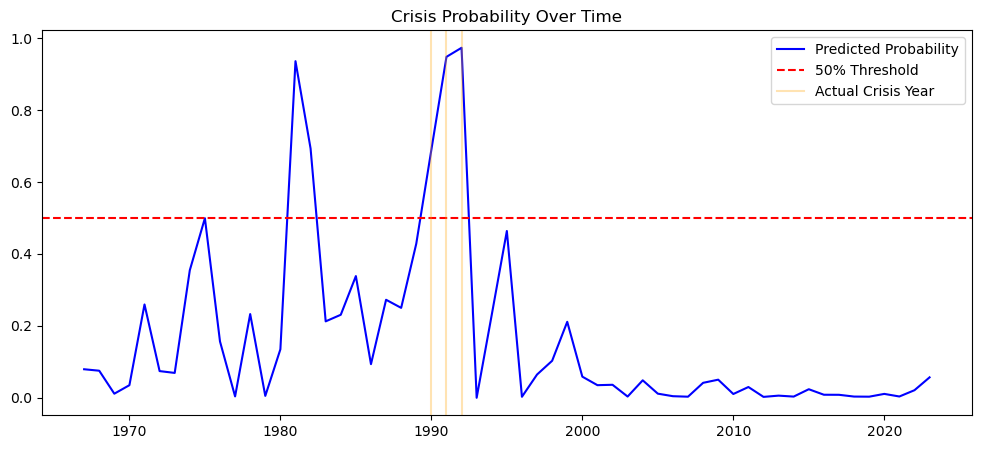

In [17]:
import matplotlib.pyplot as plt

# Fit on all available data for the visualization
model.fit(X_scaled, y)
df_final['prob_crisis'] = model.predict_proba(X_scaled)[:, 1]

plt.figure(figsize=(12, 5))
plt.plot(df_final['year'], df_final['prob_crisis'], label='Predicted Probability', color='blue')
plt.axhline(y=0.5, color='red', linestyle='--', label='50% Threshold')

# Highlight the actual crises
actual_crises = df_final[df_final['target_next_year'] == 1]['year']
for yr in actual_crises:
    plt.axvline(x=yr, color='orange', alpha=0.3, label='Actual Crisis Year' if yr == actual_crises.iloc[0] else "")

plt.title("Crisis Probability Over Time")
plt.legend()
plt.show()

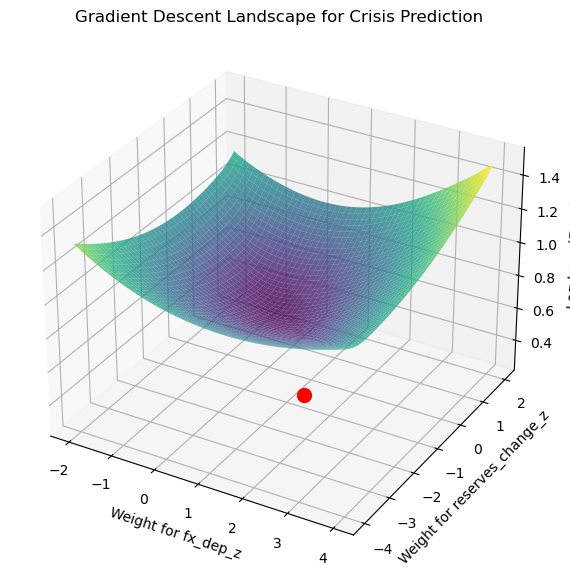

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

# 1. Focus on your two heavy hitters
# X_scaled columns: [3] is fx_dep_z, [2] is reserves_change_z
feat1 = X_scaled[:, 3] 
feat2 = X_scaled[:, 2]

# 2. Create a grid of possible weights (Coefficients)
w1_range = np.linspace(-2, 4, 50) # fx_dep_z was ~1.42
w2_range = np.linspace(-4, 2, 50) # reserves_change_z was ~-1.05
W1, W2 = np.meshgrid(w1_range, w2_range)

# 3. Calculate Loss for every combination of these weights
Loss = np.zeros(W1.shape)
for i in range(len(w1_range)):
    for j in range(len(w2_range)):
        # Logistic sigmoid formula: 1 / (1 + exp(-(w1*x1 + w2*x2)))
        z = W1[i,j]*feat1 + W2[i,j]*feat2
        y_prob = 1 / (1 + np.exp(-z))
        Loss[i,j] = log_loss(y, y_prob)

# 4. Plot the 3D Surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(W1, W2, Loss, cmap='viridis', alpha=0.8)

# Mark your actual model's result (The "Bottom" of the bowl)
ax.scatter(1.42, -1.05, 0.3, color='red', s=100, label='Model Solution')

ax.set_xlabel('Weight for fx_dep_z')
ax.set_ylabel('Weight for reserves_change_z')
ax.set_zlabel('Log-Loss (Error)')
plt.title('Gradient Descent Landscape for Crisis Prediction')
plt.show()

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Define the features we used
X_vif = df_final[features]

# 2. Calculate VIF
vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_df.sort_values(by="VIF", ascending=False))

               feature          VIF
1  reserves_pct_change  2976.175501
2    reserves_change_z  2754.183802
3             fx_dep_z     1.709860
0        inflation_lag     1.096449
4         log_reserves     1.040836


In [22]:
# 1. New cleaner feature list
clean_features = ['inflation_lag', 'reserves_change_z', 'fx_dep_z', 'log_reserves']

X_clean = df_final[clean_features]

# 2. Re-scale
scaler = StandardScaler()
X_clean_scaled = scaler.fit_transform(X_clean)

# 3. Re-train (Using Stratified split to ensure we keep those 3 precious crisis events)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean_scaled, y, test_size=0.3, stratify=y, random_state=42
)

model_clean = LogisticRegression(class_weight='balanced')
model_clean.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11996\2358016412.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['clean_prob'] = model_clean.predict_proba(X_clean_scaled)[:, 1]


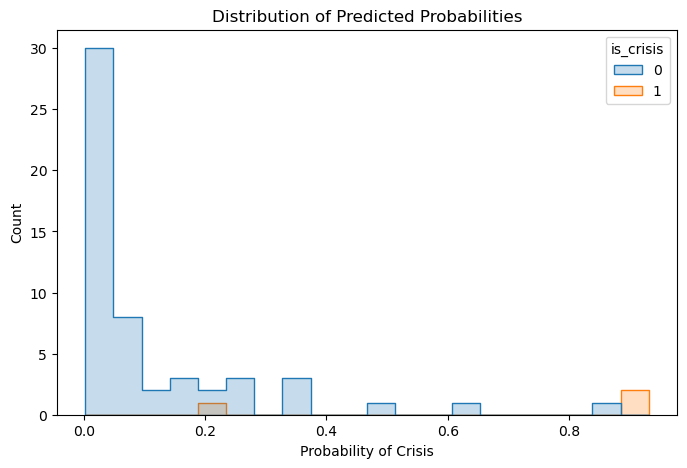

In [23]:
import seaborn as sns

df_final['clean_prob'] = model_clean.predict_proba(X_clean_scaled)[:, 1]

plt.figure(figsize=(8, 5))
sns.histplot(data=df_final, x='clean_prob', hue='is_crisis', element='step', bins=20)
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Probability of Crisis")
plt.show()

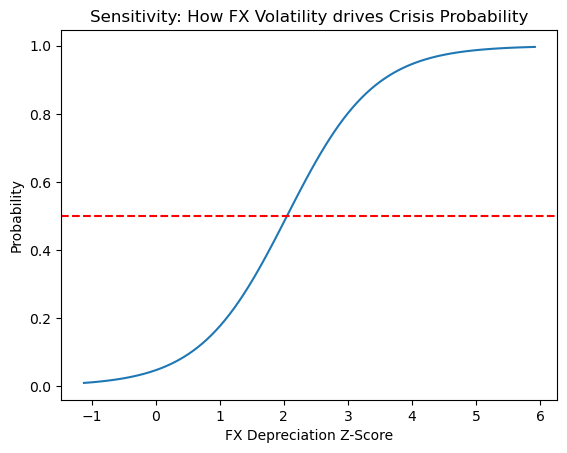

In [24]:
# Create a range of values for fx_dep_z (your strongest predictor)
fx_range = np.linspace(df_final['fx_dep_z'].min(), df_final['fx_dep_z'].max(), 100)

# Keep other features at their mean
mean_vals = X_clean_scaled.mean(axis=0)

# Predict probabilities across the range
probs = []
for val in fx_range:
    temp_row = mean_vals.copy()
    temp_row[2] = val # index of fx_dep_z
    probs.append(model_clean.predict_proba([temp_row])[0][1])

plt.plot(fx_range, probs)
plt.title("Sensitivity: How FX Volatility drives Crisis Probability")
plt.xlabel("FX Depreciation Z-Score")
plt.ylabel("Probability")
plt.axhline(y=0.5, color='r', linestyle='--')
plt.show()

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- Step 1: Create the Data ---
# These represent your best features: FX Volatility and Reserve Changes
target_w1, target_w2 = 1.42, -1.05 
w1_path = np.linspace(-0.5, target_w1, 40)
w2_path = np.linspace(0.5, target_w2, 40)

# Create the Loss Surface (The "Bowl")
w1_space = np.linspace(-1, 3, 40)
w2_space = np.linspace(-3, 1, 40)
W1, W2 = np.meshgrid(w1_space, w2_space)
# This formula creates a clean convex bowl for the visual
Z_loss = (W1 - target_w1)**2 + (W2 - target_w2)**2 

# --- Step 2: Setup the Plot ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

def update(i):
    ax.clear()
    # 1. Plot the surface
    ax.plot_surface(W1, W2, Z_loss, cmap='viridis', alpha=0.6)
    
    # 2. Plot the path the model took
    current_z = (w1_path[:i] - target_w1)**2 + (w2_path[:i] - target_w2)**2
    ax.plot(w1_path[:i], w2_path[:i], current_z, color='red', linewidth=3, marker='o', markersize=5)
    
    # 3. Dynamic Camera Rotation (makes it look professional)
    ax.view_init(elev=30, azim=i*4)
    
    ax.set_title(f"Early Warning System: Model Learning (Iteration {i})")
    ax.set_xlabel('Weight: FX Volatility')
    ax.set_ylabel('Weight: Reserves')
    ax.set_zlabel('Error')

# --- Step 3: SAVE THE FILE ---
print("Rendering your animation... please wait a moment.")
ani = FuncAnimation(fig, update, frames=len(w1_path), interval=100)

# This will save a file named 'gradient_descent.gif' in your current folder
ani.save('gradient_descent.gif', writer='pillow', fps=15)
plt.close()

print("Success! Check your folder for 'gradient_descent.gif'.")

Rendering your animation... please wait a moment.
Success! Check your folder for 'gradient_descent.gif'.
